# Order and Customer Exploratory Data Analysis

## Notebook purpose

This notebook explores order-level and customer-level patterns in the e-commerce dataset.

# Import Important Libraries

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", "{:,.2f}".format)

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (12, 6)

CURRENT_DIR = Path.cwd().resolve()
PROJECT_ROOT = CURRENT_DIR.parent if CURRENT_DIR.name == "notebooks" else CURRENT_DIR
DATA_DIR = PROJECT_ROOT / "data"

print(f"Project root: {PROJECT_ROOT}")

Project root: C:\Users\ankur\OneDrive\Desktop\E-Commerce Project


# Load And Prepare Customer And Order Data

In [2]:
customers_df = pd.read_csv(DATA_DIR / "customer_master.csv")
orders_df = pd.read_csv(DATA_DIR / "ecommerce_sales_customer_analytics_150k.csv")
orders_df["order_date"] = pd.to_datetime(
    orders_df["order_date"],
    errors="coerce"
)

orders_df["return_label"] = (
    orders_df["return_status"] == "Returned"
).astype(int)

order_customer_df = orders_df.merge(
    customers_df,
    on="customer_id",
    how="left",
    suffixes=("", "_master"),
    validate="m:1"
)

print(f"Orders before join: {len(orders_df):,}")
print(f"Orders after join:  {len(order_customer_df):,}")
print(f"Missing customer matches: {order_customer_df['customer_name_master'].isna().sum():,}")

Orders before join: 138,116
Orders after join:  138,116
Missing customer matches: 0


In [5]:
order_customer_df.head()

,order_id,order_date,order_time,order_status,sales_channel,customer_id,customer_name,customer_age,gender,customer_segment,customer_type,customer_city,customer_state,customer_country,region,customer_postal_code,payment_method,payment_status,currency,shipping_method,warehouse,delivery_days,estimated_delivery_days,delivery_status,return_status,return_reason,customer_rating,review_sentiment,customer_review,marketing_channel,campaign_name,coupon_code,loyalty_points_earned,loyalty_points_redeemed,quantity,gross_sales,discount_amount,tax_amount,shipping_cost,net_sales,product_cost,profit,profit_margin_percentage,customer_lifetime_value,is_repeat_customer,customer_order_count,return_label,customer_name_master,customer_age_master,gender_master,customer_segment_master,customer_city_master,customer_state_master,customer_country_master,region_master,customer_postal_code_master,customer_acquisition_cost
0,ORD-301242,2023-11-06,16:37:47,Completed,Mobile App,CUST-003102,Jasmine Ryan,55,Male,Consumer,Loyal,Lake Williamberg,Texas,USA,South,86040,Digital Wallet,Paid,USD,Standard,WH-003,3.00,3.00,On Time,NaN,NaN,3.50,Positive,Satisfied with the purchase.,Direct,Default_Campaign,NaN,94,44,5,"1,350.19",477.89,61.07,12.03,945.40,588.33,345.04,36.50,"12,459.68",True,11,0,Jasmine Ryan,55,Male,Consumer,Lake Williamberg,Texas,USA,South,86040,73.06
1,ORD-773460,2025-12-24,01:22:36,Completed,Website,CUST-003124,Scott Chase,26,Male,Premium,Loyal,Kristyport,Baden-Württemberg,Germany,South,62538,Debit Card,Pending,EUR,Economy,WH-005,10.00,10.00,On Time,NaN,NaN,3.60,Positive,Good value for money.,Direct,Default_Campaign,NaN,201,171,8,"3,144.64","1,456.06",320.83,9.00,"2,018.41","2,031.88",-22.47,-1.11,"13,032.48",True,11,0,Scott Chase,26,Male,Premium,Kristyport,Baden-Württemberg,Germany,South,62538,67.27
2,ORD-449374,2021-07-05,14:24:21,Completed,Mobile App,CUST-012496,Marc Wheeler,69,Female,Premium,Loyal,Singletonhaven,New York,USA,East,19993,Cash on Delivery,Paid,USD,Express,WH-015,3.00,3.00,On Time,NaN,NaN,4.30,Positive,Good product. Works as expected.,YouTube,NaN,NaN,46,16,5,522.81,97.30,29.79,13.05,468.35,257.73,197.57,42.18,"6,159.44",True,6,0,Marc Wheeler,69,Female,Premium,Singletonhaven,New York,USA,East,19993,52.02
3,ORD-567636,2023-01-21,07:20:26,Completed,Social Media,CUST-023928,Jennifer Smith,65,Male,Consumer,Loyal,Wigginsstad,North Carolina,USA,South,66329,Debit Card,Paid,USD,Express,WH-010,2.00,2.00,On Time,NaN,NaN,3.50,Positive,Satisfied with the purchase.,Email Marketing,NaN,NaN,54,10,2,544.62,53.34,34.39,20.85,546.52,277.84,247.83,45.35,"5,638.30",True,7,0,Jennifer Smith,65,Male,Consumer,Wigginsstad,North Carolina,USA,South,66329,65.91
4,ORD-820028,2022-05-13,09:46:21,Completed,Social Media,CUST-012730,Jessica Wang,34,Female,Consumer,Loyal,New Michaelton,Gujarat,India,West,77306,Digital Wallet,Paid,INR,Standard,WH-013,6.00,5.00,Delayed,NaN,NaN,3.00,Neutral,Mixed feelings about this purchase.,Direct,NaN,NaN,278,147,6,"2,474.52",133.63,421.35,23.03,"2,785.27","1,231.88","1,530.36",54.94,"13,240.10",True,8,0,Jessica Wang,34,Female,Consumer,New Michaelton,Gujarat,India,West,77306,66.26


# Overall Order And Return Summary

In [6]:
overall_summary = pd.Series({
    "total_orders": len(order_customer_df),
    "total_returned_orders": order_customer_df["return_label"].sum(),
    "overall_return_rate_percent": round(
        order_customer_df["return_label"].mean() * 100, 2
    ),
    "average_net_sales": round(
        order_customer_df["net_sales"].mean(), 2
    ),
    "average_profit": round(
        order_customer_df["profit"].mean(), 2
    )
})

display(overall_summary)

total_orders                  138,116.00
total_returned_orders           9,462.00
overall_return_rate_percent         6.85
average_net_sales               1,282.50
average_profit                    551.32
dtype: float64

# Returns Over Time

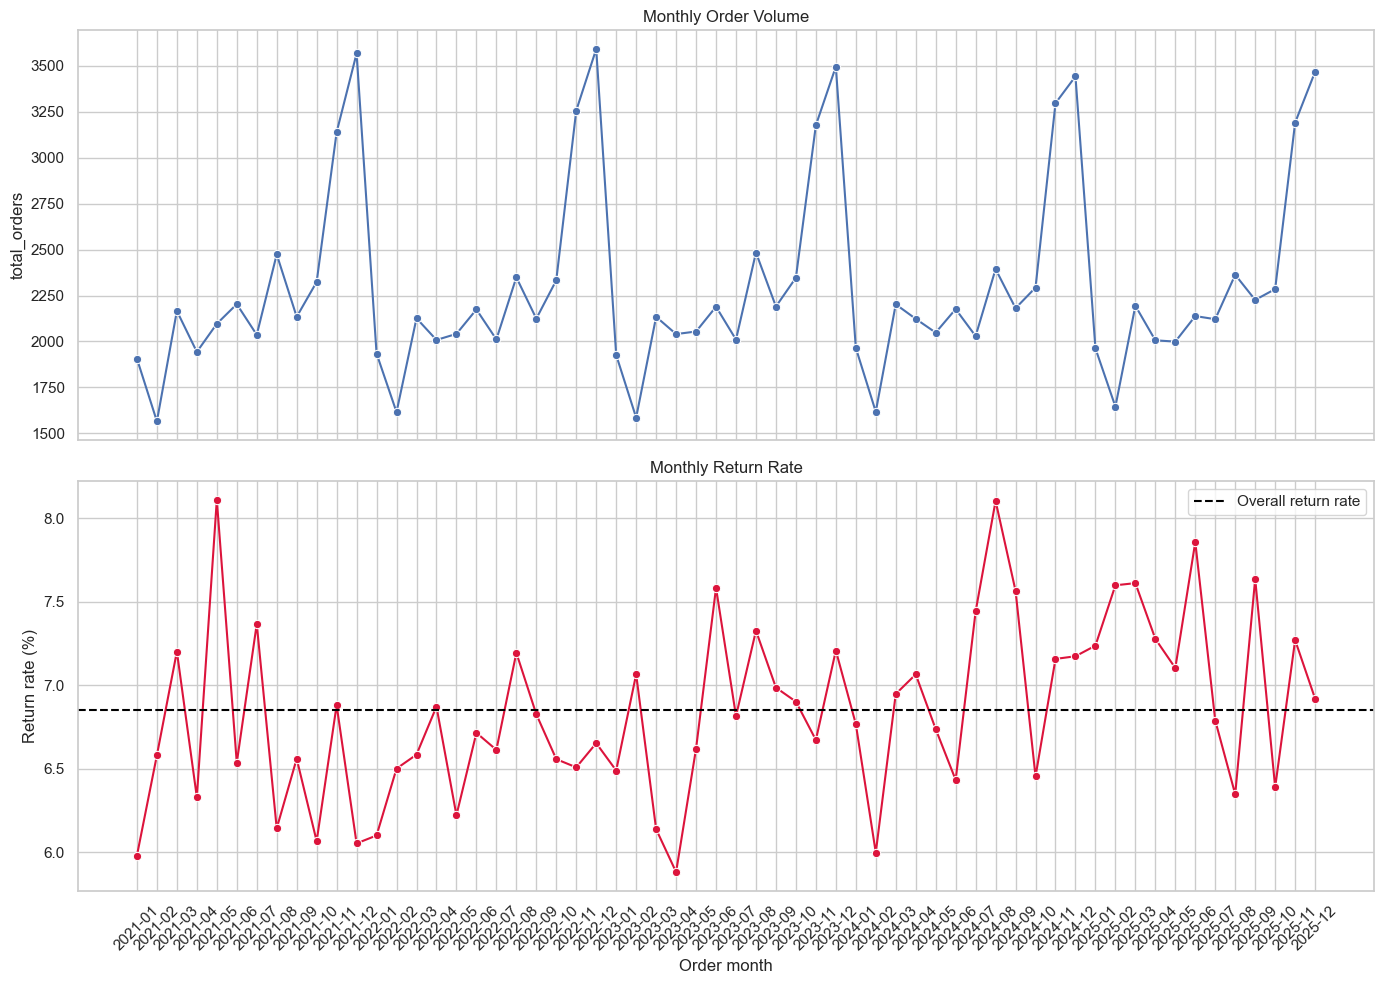

In [7]:
monthly_summary = (
    order_customer_df
    .assign(order_month=order_customer_df["order_date"].dt.to_period("M"))
    .groupby("order_month", as_index=False)
    .agg(
        total_orders=("order_id", "count"),
        return_rate=("return_label", "mean")
    )
)

monthly_summary["order_month"] = monthly_summary["order_month"].astype(str)
monthly_summary["return_rate_percent"] = monthly_summary["return_rate"] * 100

fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

sns.lineplot(
    data=monthly_summary,
    x="order_month",
    y="total_orders",
    ax=axes[0],
    marker="o"
)
axes[0].set_title("Monthly Order Volume")
axes[0].set_xlabel("")
axes[0].tick_params(axis="x", rotation=45)

sns.lineplot(
    data=monthly_summary,
    x="order_month",
    y="return_rate_percent",
    ax=axes[1],
    marker="o",
    color="crimson"
)
axes[1].axhline(
    overall_summary["overall_return_rate_percent"],
    linestyle="--",
    color="black",
    label="Overall return rate"
)
axes[1].set_title("Monthly Return Rate")
axes[1].set_xlabel("Order month")
axes[1].set_ylabel("Return rate (%)")
axes[1].tick_params(axis="x", rotation=45)
axes[1].legend()

plt.tight_layout()
plt.show()

# Return Rate By Customer Segment

,customer_segment,total_orders,returned_orders,return_rate,average_net_sales,return_rate_percent
0,Business,13777,972,0.07,"1,289.13",7.06
2,Premium,34746,2381,0.07,"1,274.10",6.85
1,Consumer,75636,5175,0.07,"1,285.12",6.84
3,VIP,13957,934,0.07,"1,282.74",6.69


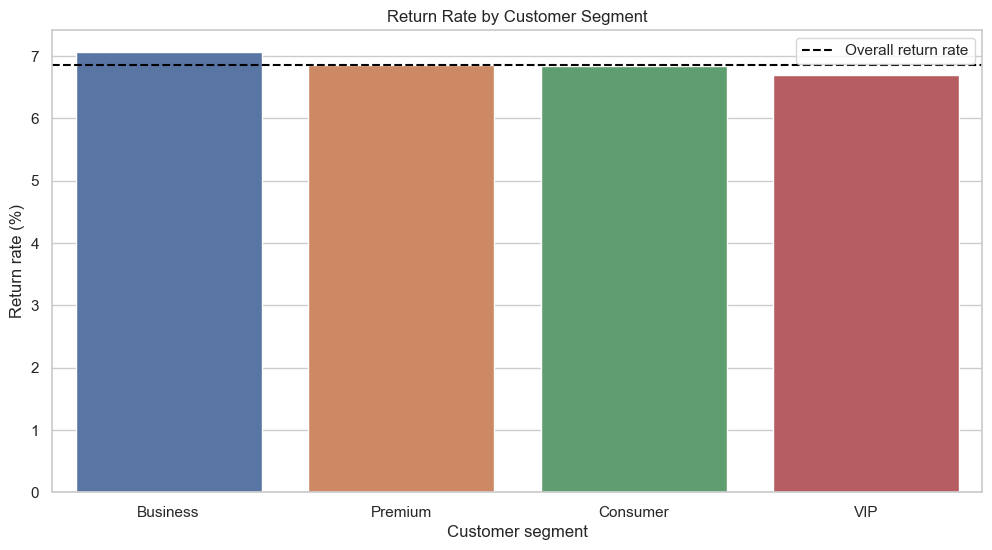

In [8]:
segment_summary = (
    order_customer_df
    .groupby("customer_segment", as_index=False)
    .agg(
        total_orders=("order_id", "count"),
        returned_orders=("return_label", "sum"),
        return_rate=("return_label", "mean"),
        average_net_sales=("net_sales", "mean")
    )
)

segment_summary["return_rate_percent"] = (
    segment_summary["return_rate"] * 100
).round(2)

segment_summary = segment_summary.sort_values(
    "return_rate_percent",
    ascending=False
)

display(segment_summary)

sns.barplot(
    data=segment_summary,
    x="customer_segment",
    y="return_rate_percent",
    hue="customer_segment",
    legend=False
)
plt.axhline(
    overall_summary["overall_return_rate_percent"],
    linestyle="--",
    color="black",
    label="Overall return rate"
)
plt.title("Return Rate by Customer Segment")
plt.xlabel("Customer segment")
plt.ylabel("Return rate (%)")
plt.legend()
plt.show()

# Return Rate By Region And Country


,region,total_orders,return_rate,return_rate_percent
0,Central,29627,0.07,7.11
2,North,16624,0.07,7.11
4,West,26273,0.07,6.92
3,South,43990,0.07,6.76
1,East,21602,0.06,6.40


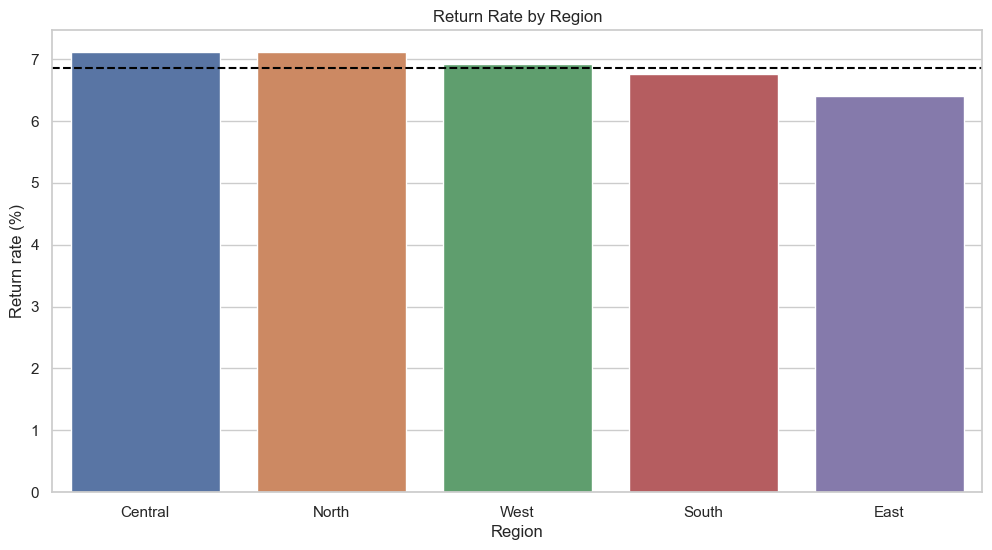

In [11]:
region_summary = (
    order_customer_df
    .groupby("region", as_index=False)
    .agg(
        total_orders=("order_id", "count"),
        return_rate=("return_label", "mean")
    )
)

region_summary["return_rate_percent"] = (
    region_summary["return_rate"] * 100
).round(2)

region_summary = region_summary.sort_values(
    "return_rate_percent",
    ascending=False
)

display(region_summary)

sns.barplot(
    data=region_summary,
    x="region",
    y="return_rate_percent",
    hue="region",
    legend=False
)
plt.axhline(
    overall_summary["overall_return_rate_percent"],
    linestyle="--",
    color="black"
)
plt.title("Return Rate by Region")
plt.xlabel("Region")
plt.ylabel("Return rate (%)")
plt.show()

,customer_country,total_orders,return_rate,return_rate_percent
1,Canada,7015,0.07,7.31
2,Germany,11593,0.07,7.15
0,Australia,6794,0.07,6.99
3,India,5707,0.07,6.89
5,UK,20235,0.07,6.87
6,USA,82600,0.07,6.79
4,UAE,4172,0.06,6.16


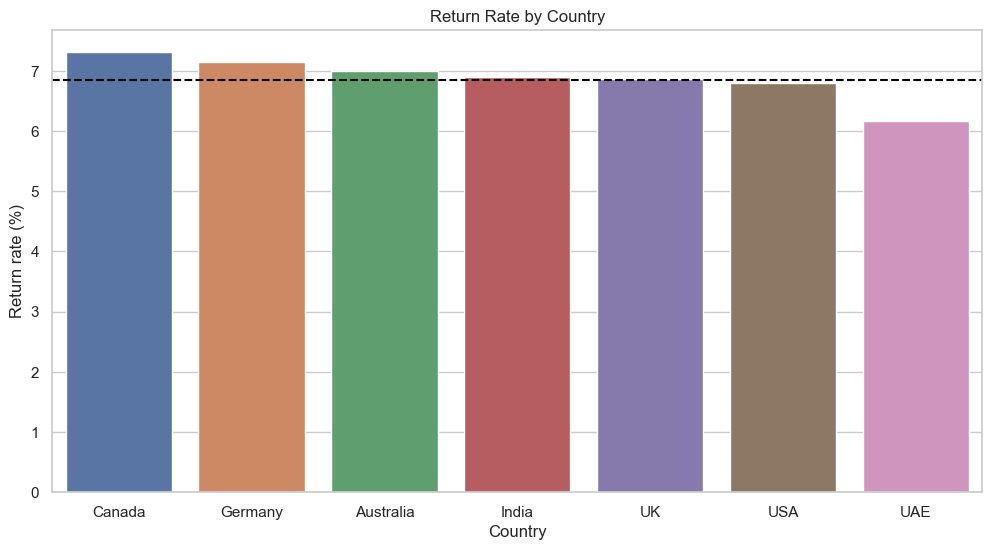

In [13]:
country_summary = (
    order_customer_df
    .groupby("customer_country", as_index=False)
    .agg(
        total_orders=("order_id", "count"),
        return_rate=("return_label", "mean")
    )
)

country_summary["return_rate_percent"] = (
    country_summary["return_rate"] * 100
).round(2)

country_summary = country_summary.sort_values(
    "return_rate_percent",
    ascending=False
)

display(country_summary)
sns.barplot(
    data=country_summary,
    x="customer_country",
    y="return_rate_percent",
    hue="customer_country",
    legend=False
)
plt.axhline(
    overall_summary["overall_return_rate_percent"],
    linestyle="--",
    color="black"
)
plt.title("Return Rate by Country")
plt.xlabel("Country")
plt.ylabel("Return rate (%)")
plt.show()

# Return Rate By Customer Age Group

,age_group,total_orders,return_rate,return_rate_percent
0,18–24,16961,0.07,6.87
1,25–34,24537,0.07,6.73
2,35–44,24542,0.07,7.02
3,45–54,23849,0.07,6.70
4,55–64,24213,0.07,6.83
5,65+,24014,0.07,6.96


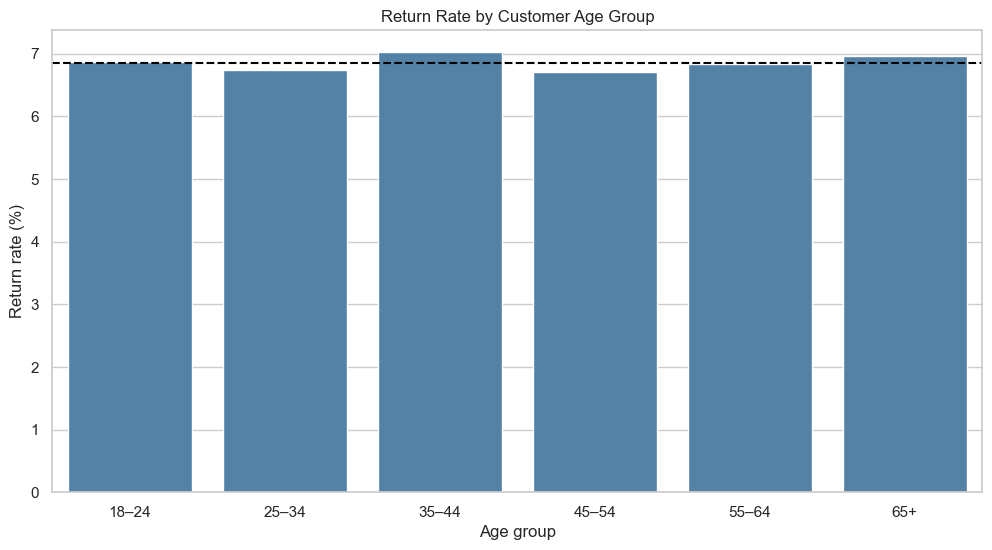

In [14]:
age_bins = [0, 24, 34, 44, 54, 64, 100]
age_labels = ["18–24", "25–34", "35–44", "45–54", "55–64", "65+"]

order_customer_df["age_group"] = pd.cut(
    order_customer_df["customer_age"],
    bins=age_bins,
    labels=age_labels,
    include_lowest=True
)

age_summary = (
    order_customer_df
    .groupby("age_group", observed=False, as_index=False)
    .agg(
        total_orders=("order_id", "count"),
        return_rate=("return_label", "mean")
    )
)

age_summary["return_rate_percent"] = (
    age_summary["return_rate"] * 100
).round(2)

display(age_summary)

sns.barplot(
    data=age_summary,
    x="age_group",
    y="return_rate_percent",
    color="steelblue"
)
plt.axhline(
    overall_summary["overall_return_rate_percent"],
    linestyle="--",
    color="black"
)
plt.title("Return Rate by Customer Age Group")
plt.xlabel("Age group")
plt.ylabel("Return rate (%)")
plt.show()

# Return Rate By Sales Channel And Shipping Method

In [16]:
def create_return_rate_summary(dataframe, group_column):
    summary = (
        dataframe
        .groupby(group_column, as_index=False)
        .agg(
            total_orders=("order_id", "count"),
            return_rate=("return_label", "mean"),
            average_net_sales=("net_sales", "mean")
        )
    )

    summary["return_rate_percent"] = (
        summary["return_rate"] * 100
    ).round(2)

    return summary.sort_values("return_rate_percent", ascending=False)

,sales_channel,total_orders,return_rate,average_net_sales,return_rate_percent
0,Marketplace,20698,0.07,"1,289.80",6.93
1,Mobile App,55318,0.07,"1,280.50",6.91
3,Website,48237,0.07,"1,282.31",6.87
2,Social Media,13863,0.06,"1,280.28",6.41


,shipping_method,total_orders,return_rate,average_net_sales,return_rate_percent
1,Express,34373,0.07,"1,280.18",6.93
0,Economy,27824,0.07,"1,280.82",6.88
3,Standard,62006,0.07,"1,281.64",6.85
2,Same Day,13913,0.07,"1,295.47",6.60


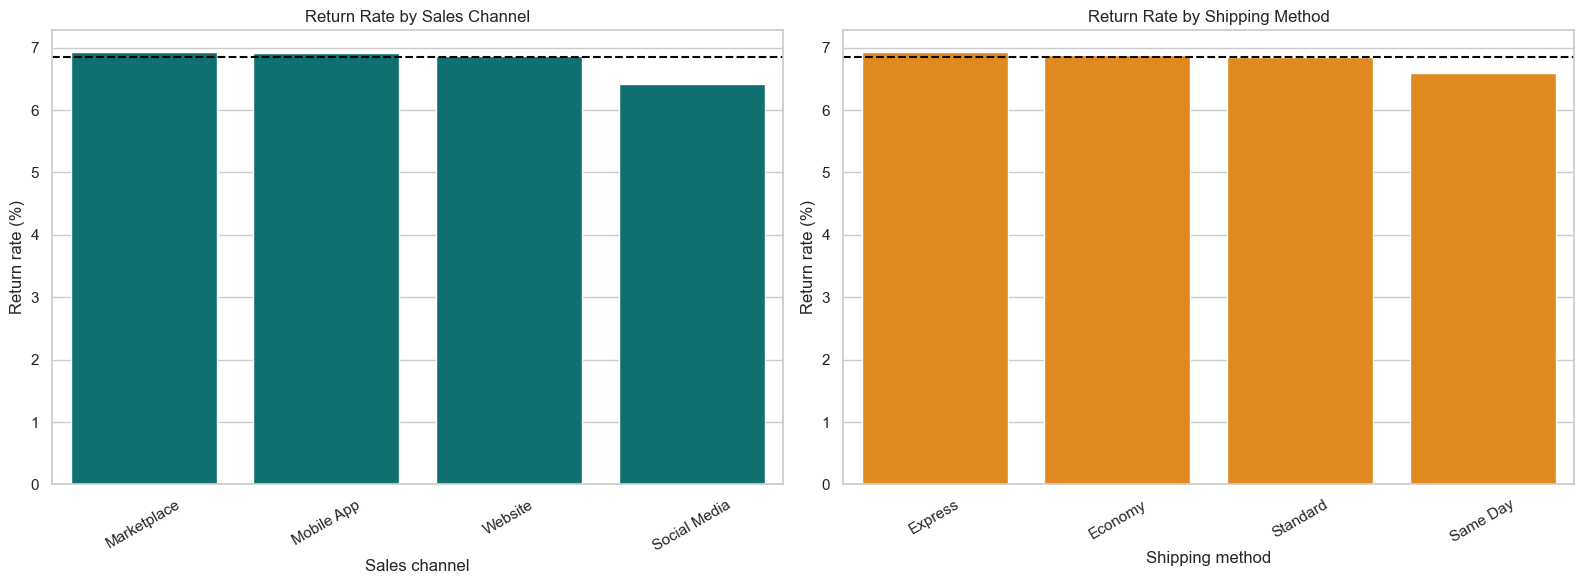

In [17]:
sales_channel_summary = create_return_rate_summary(
    order_customer_df,
    "sales_channel"
)

shipping_method_summary = create_return_rate_summary(
    order_customer_df,
    "shipping_method"
)

display(sales_channel_summary)
display(shipping_method_summary)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(
    data=sales_channel_summary,
    x="sales_channel",
    y="return_rate_percent",
    ax=axes[0],
    color="teal"
)
axes[0].axhline(
    overall_summary["overall_return_rate_percent"],
    linestyle="--",
    color="black"
)
axes[0].set_title("Return Rate by Sales Channel")
axes[0].set_xlabel("Sales channel")
axes[0].set_ylabel("Return rate (%)")
axes[0].tick_params(axis="x", rotation=30)

sns.barplot(
    data=shipping_method_summary,
    x="shipping_method",
    y="return_rate_percent",
    ax=axes[1],
    color="darkorange"
)
axes[1].axhline(
    overall_summary["overall_return_rate_percent"],
    linestyle="--",
    color="black"
)
axes[1].set_title("Return Rate by Shipping Method")
axes[1].set_xlabel("Shipping method")
axes[1].set_ylabel("Return rate (%)")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

# Discount And Order-Value Analysis

In [20]:
order_customer_df["discount_group"] = pd.qcut(
    order_customer_df["discount_amount"],
    q=4,
    duplicates="drop"
)

order_customer_df["net_sales_group"] = pd.qcut(
    order_customer_df["net_sales"],
    q=4,
    duplicates="drop"
)

discount_summary = create_return_rate_summary(
    order_customer_df,
    "discount_group"
)

sales_value_summary = create_return_rate_summary(
    order_customer_df,
    "net_sales_group"
)

display(discount_summary)
display(sales_value_summary)

C:\Users\ankur\AppData\Local\Temp\ipykernel_7540\1276131579.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(group_column, as_index=False)
C:\Users\ankur\AppData\Local\Temp\ipykernel_7540\1276131579.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(group_column, as_index=False)


,discount_group,total_orders,return_rate,average_net_sales,return_rate_percent
0,"(-0.001, 26.328]",34529,0.27,842.80,27.40
1,"(26.328, 103.285]",34529,0.00,696.56,0.00
2,"(103.285, 277.125]",34529,0.00,"1,321.55",0.00
3,"(277.125, 6759.02]",34529,0.00,"2,269.11",0.00


,net_sales_group,total_orders,return_rate,average_net_sales,return_rate_percent
3,"(1744.582, 16218.0]",34529,0.08,"2,899.89",7.63
2,"(950.76, 1744.582]",34529,0.07,"1,304.90",6.80
1,"(448.2, 950.76]",34528,0.07,687.65,6.57
0,"(5.7989999999999995, 448.2]",34530,0.06,237.58,6.40


# Customer Behavior Fields

In [21]:
customer_type_summary = create_return_rate_summary(
    order_customer_df,
    "customer_type"
)

repeat_customer_summary = create_return_rate_summary(
    order_customer_df,
    "is_repeat_customer"
)

display(customer_type_summary)
display(repeat_customer_summary)

print("Customer order count summary:")
display(order_customer_df["customer_order_count"].describe())

,customer_type,total_orders,return_rate,average_net_sales,return_rate_percent
2,Returning,8335,0.07,"1,262.55",6.95
0,Loyal,129447,0.07,"1,283.73",6.85
1,New,334,0.06,"1,303.76",6.29


,is_repeat_customer,total_orders,return_rate,average_net_sales,return_rate_percent
1,True,137782,0.07,"1,282.45",6.85
0,False,334,0.06,"1,303.76",6.29


Customer order count summary:


count   138,116.00
mean          6.99
std           2.44
min           1.00
25%           5.00
50%           7.00
75%           9.00
max          20.00
Name: customer_order_count, dtype: float64